# Tech Challenge — Fase 1 (IADT)
## Classificação de câncer de mama

Este notebook apresenta, de forma visual, as principais etapas do sistema de
classificação de câncer de mama. A lógica de carregamento e preparação dos dados,
treinamento dos modelos, avaliação e explicabilidade está concentrada no pacote
`techchallenge`, localizado em `src/`. Aqui, utilizamos esse pacote para conduzir
a análise e discutir os resultados.

Percurso da análise: exploração dos dados → pré-processamento → modelagem →
avaliação → explicabilidade.

## Preparação do ambiente
Nesta etapa, acrescentamos o diretório `src/` ao caminho de busca do Python.
Assim, o pacote pode ser importado diretamente, sem instalação prévia.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from techchallenge import config
from techchallenge.data import estruturado as dados
from techchallenge.models import estruturado as modelos_estr
from techchallenge.evaluation import metrics, explicabilidade

sns.set_theme(style="whitegrid")
OUT = config.garantir_outputs()
print("Pacote techchallenge importado. Diretório de saída: outputs/")

Pacote techchallenge importado. Diretório de saída: outputs/


## 1. Carregamento dos dados
A função `carregar_dados()` lê o arquivo CSV e remove duas colunas antes da análise:
`id` e `Unnamed: 32`. A primeira contém um identificador diferente para cada registro
e não descreve nenhuma característica clínica da amostra. A segunda está inteiramente
vazia e foi criada apenas pela vírgula existente no fim das linhas do arquivo. Como
nenhuma delas fornece informação útil para o aprendizado do modelo, ambas são
desconsideradas.

In [2]:
df = dados.carregar_dados()
print("Formato:", df.shape)
df.head()

Formato: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Análise exploratória dos dados (EDA)
Antes de treinar os modelos, examinamos a distribuição das classes e a relação
entre as variáveis.

{'B': 357, 'M': 212}


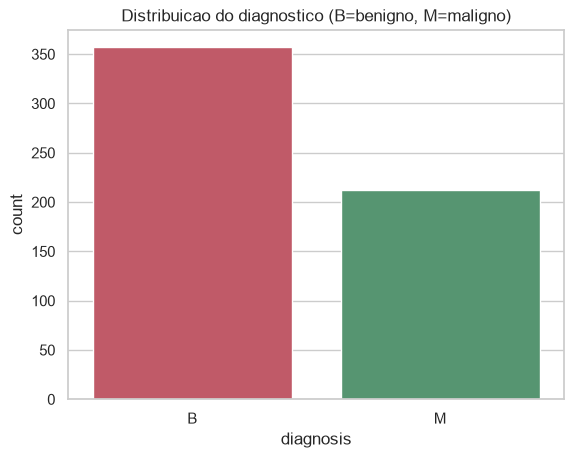

In [3]:
counts = df["diagnosis"].value_counts()
print(counts.to_dict())
sns.countplot(data=df, x="diagnosis", hue="diagnosis", order=["B","M"],
              palette=["#4c9f70","#d1495b"], legend=False)
plt.title("Distribuição dos diagnósticos (B = benigno, M = maligno)"); plt.show()

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


As oito variáveis com maior correlação positiva com o diagnóstico de malignidade:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
Name: diagnosis, dtype: float64


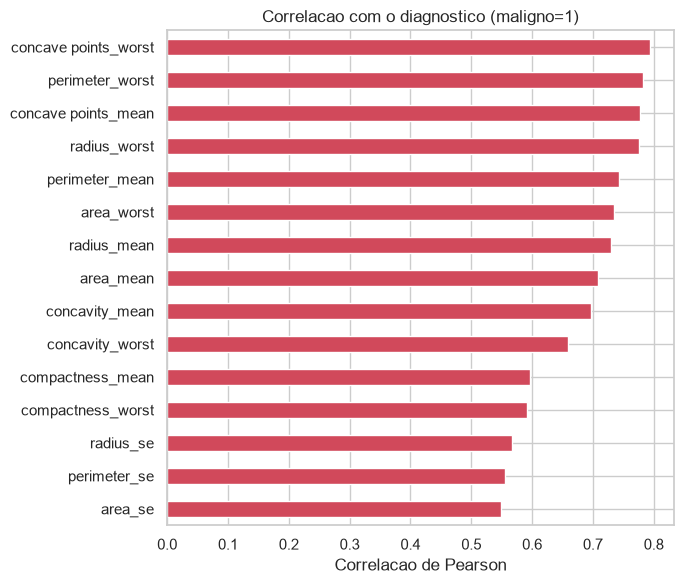

In [5]:
df_corr = df.copy()
df_corr["diagnosis"] = df_corr["diagnosis"].map({"M":1,"B":0})
corr = df_corr.corr()["diagnosis"].drop("diagnosis").sort_values(ascending=False)
print("As oito variáveis com maior correlação positiva com o diagnóstico de malignidade:")
print(corr.head(8).round(3))
corr.head(15).plot(kind="barh", color="#d1495b", figsize=(7,6))
plt.gca().invert_yaxis(); plt.title("Correlação com o diagnóstico (maligno = 1)")
plt.xlabel("Correlação de Pearson"); plt.tight_layout(); plt.show()

## 3. Pré-processamento
A base contém 357 casos benignos e 212 malignos. Como as classes não aparecem na
mesma proporção, utilizamos uma divisão estratificada: 80% dos dados são destinados
ao treinamento e 20% ao teste, mantendo aproximadamente a proporção original das
classes nos dois conjuntos. Essa escolha reduz o risco de uma divisão aleatória
produzir uma proporção de casos malignos diferente da observada na base e tornar a
avaliação menos representativa. A codificação da variável-alvo é realizada pelo
próprio pacote.

In [6]:
X_train, X_test, y_train, y_test = dados.preparar_treino_teste(df)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (455, 30) | Teste: (114, 30)


## 4. Modelagem
Nesta etapa, treinamos seis modelos fornecidos pelo pacote: Regressão Logística,
Árvore de Decisão, KNN, Random Forest, Gradient Boosting e SVM. Cada modelo é
organizado em um *pipeline* que reúne as transformações necessárias e o respectivo
classificador.

In [7]:
modelos = modelos_estr.construir_modelos()
rotulos_modelos = {
    "Regressao Logistica": "Regressão Logística",
    "Arvore de Decisao": "Árvore de Decisão",
    "KNN": "KNN",
}
for nome, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    print(rotulos_modelos.get(nome, nome), "— treinamento concluído")

Regressão Logística — treinamento concluído
Árvore de Decisão — treinamento concluído
KNN — treinamento concluído
Random Forest — treinamento concluído
Gradient Boosting — treinamento concluído
SVM — treinamento concluído


## 5. Avaliação
Na avaliação dos modelos, priorizamos o **recall dos casos malignos**, que mede a
proporção de casos realmente malignos identificados corretamente. Essa escolha se
deve ao impacto dos falsos negativos: classificar um caso maligno como benigno pode
adiar a realização de exames complementares e a investigação clínica. Ainda assim,
o recall não é analisado isoladamente; também consideramos a acurácia, o F1-score e
as matrizes de confusão para obter uma visão mais completa do desempenho.

In [8]:
linhas = []
for nome, pipe in modelos.items():
    y_pred = pipe.predict(X_test)
    linhas.append({"Modelo": nome, **metrics.metricas(y_test, y_pred)})
res_df = pd.DataFrame(linhas).set_index("Modelo").rename(index=rotulos_modelos).round(4)
res_df

,Accuracy,Recall (maligno),F1 (maligno)
Modelo,,,
Regressão Logística,0.9649,0.9286,0.9512
Árvore de Decisão,0.9211,0.8333,0.8861
KNN,0.9561,0.9048,0.9383
Random Forest,0.9737,0.9286,0.9630
Gradient Boosting,0.9649,0.9048,0.9500
SVM,0.9737,0.9286,0.9630


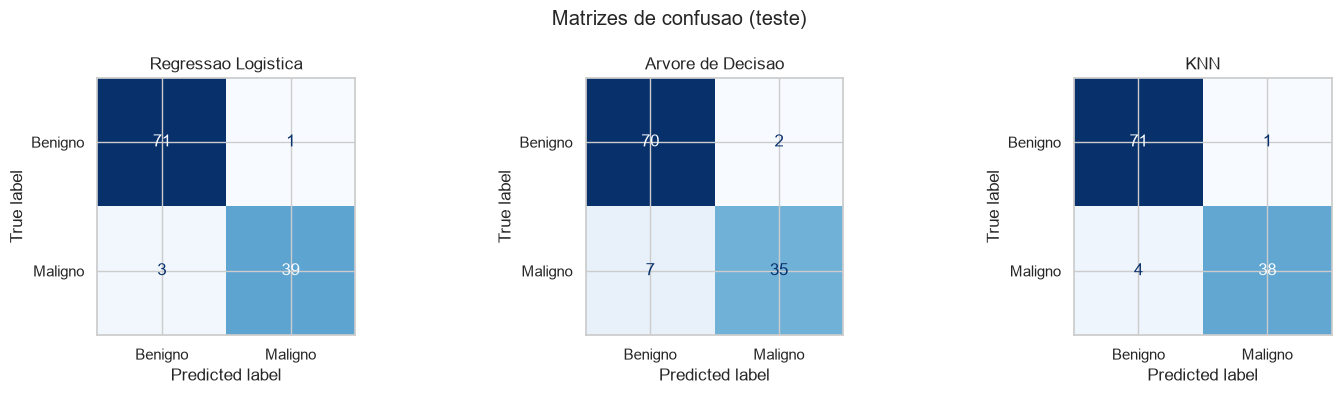

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (nome, pipe) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["Benigno","Maligno"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(rotulos_modelos.get(nome, nome))
plt.suptitle("Matrizes de confusão no conjunto de teste"); plt.tight_layout(); plt.show()

## 6. Explicabilidade
Para compreender quais variáveis mais influenciam as previsões, utilizamos as
funções de explicabilidade do pacote. Os gráficos são salvos em `outputs/` e
exibidos a seguir.

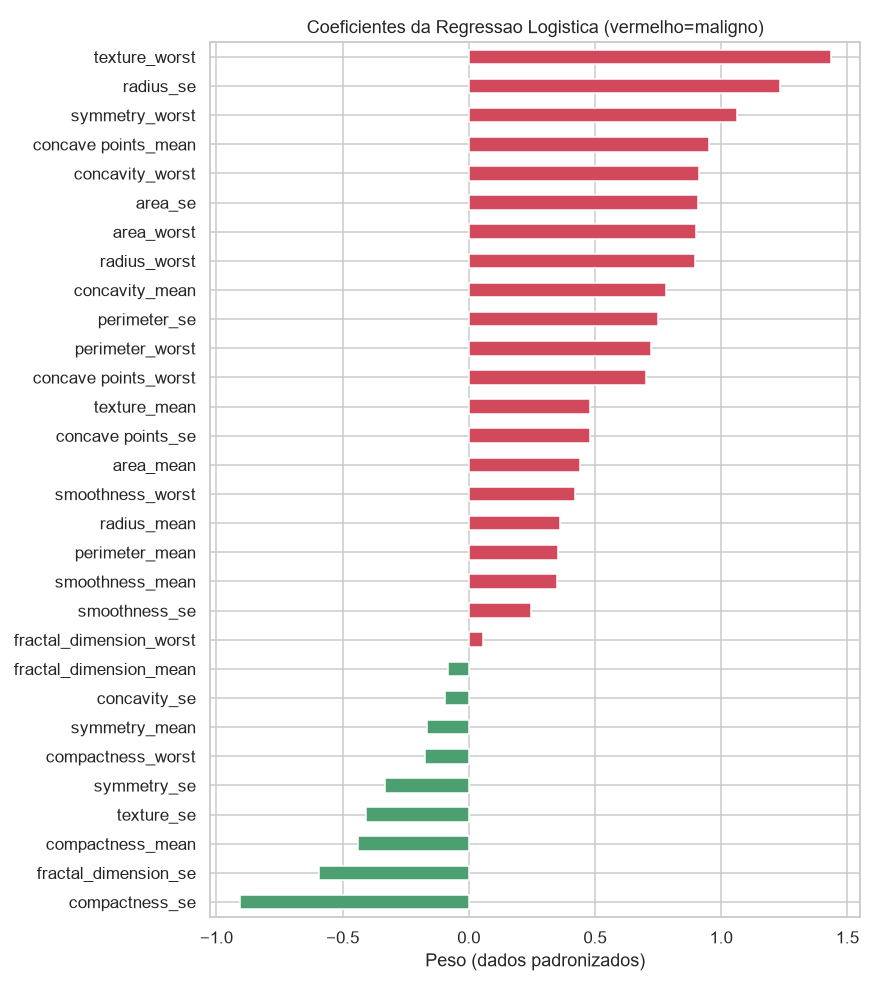

In [10]:
explicabilidade.feature_importance_logistica(
    modelos["Regressao Logistica"], X_train.columns,
    OUT / "estruturado_feature_importance.png")
display(Image(str(OUT / "estruturado_feature_importance.png")))

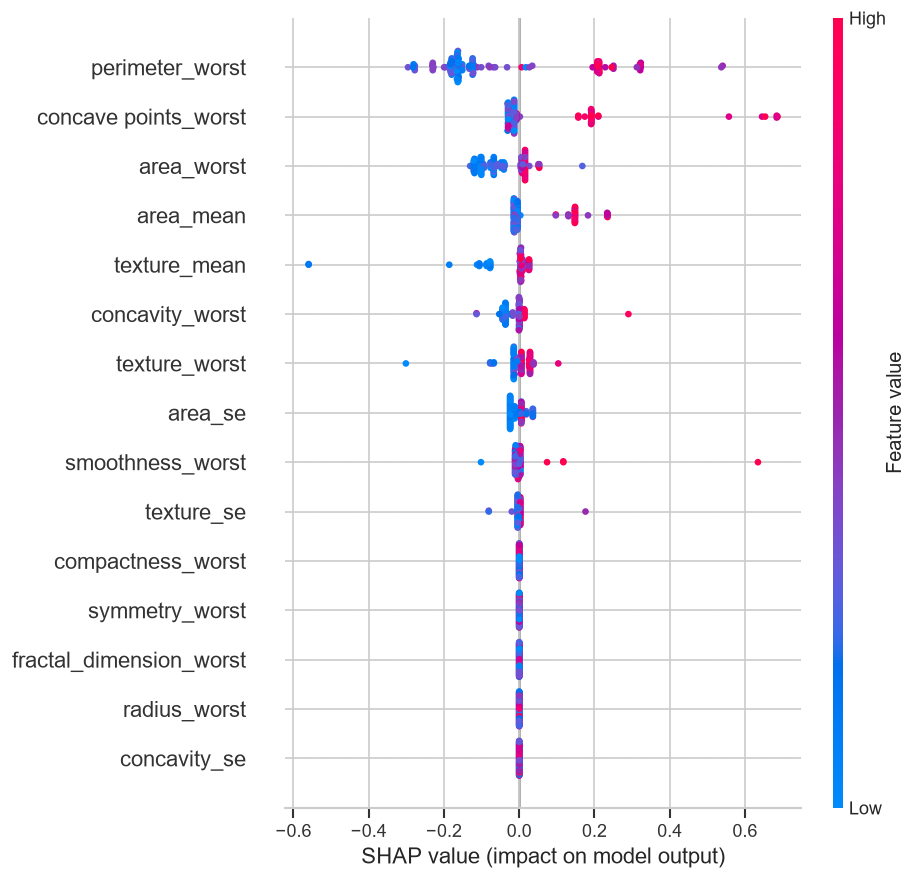

In [11]:
explicabilidade.shap_arvore(
    modelos["Arvore de Decisao"], X_test, X_train.columns,
    OUT / "estruturado_shap.png")
display(Image(str(OUT / "estruturado_shap.png")))

## 7. Conclusão

Na separação de teste utilizada, a **Regressão Logística**, o **Random Forest** e a
**SVM** alcançaram o maior recall para a classe maligna: aproximadamente 0,93, com
três falsos negativos cada. Entre eles, Random Forest e SVM também obtiveram os
melhores resultados de acurácia e F1.

As análises de explicabilidade destacaram variáveis associadas ao tamanho e à
irregularidade do núcleo, como `concave points`, `perimeter_worst` e `area_worst`.
A importância dessas variáveis apareceu de forma consistente na correlação, nos
coeficientes da Regressão Logística e na análise SHAP da Árvore de Decisão.

A etapa adicional com uma CNN aplicada a mamografias pode ser executada
pelo comando `python -m techchallenge --com-cnn`. A discussão completa
está disponível em `docs/RELATORIO_TECNICO.md`.